# Managing data with FNQS
---

When performing simulations, each run produces two kinds of persistent data that we must store:

- **Hyperparameter spec** - feature space, learning rate, etc.
- **Training statistics** — energy, acceptance rate, wall-clock time logged at every step.
- **Model weights** — the optimised variational parameters needed to evaluate $\psi$ after training.

This tutorial showcases a simple two-phase workflow which we find works well enough for several use-cases.
For beginners, we suggest to look into this approach.

1. **Training phase** — write a `meta.json` with the run configuration, attach a `JsonLog` to
   capture statistics, and save the final state with `vs.save`.
2. **Analysis phase** — reload `meta.json` to reconstruct the Hamiltonian,
   restore the trained model with `FoundationalQuantumState.load`, and compute new observables.

The system is the same 1D transverse-field Ising chain as in **[Tutorial 1](1.%20FNQS%20training%20basics.ipynb)**.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORM_NAME", "cpu")

import json
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

import netket as nk
import netket_foundation as nkf
from netket_foundation._src.model.vit import ViTFNQS
from netket_foundation.expectation_value import ISState

∣NK⟩ Tip: Prefer the new nk.driver.VMC_SR over VMC which supports minSR and SPRING.

## System and model
---

1D transverse-field Ising chain, $L = 10$, $h \in [0.75, 2.0]$, 8 replicas — identical to Tutorial 1.
See that notebook for a detailed walkthrough of each building block.

In [2]:
import optax

L  = 10
hi = nk.hilbert.Spin(0.5, L)

ps = nkf.ParameterSpace(N=1, min=0.75, max=2.0)

def create_operator(params):
    h     = params[0]
    ha_X  = sum(nkf.operator.sigmax(hi, i) for i in range(L))
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi, i) @ nkf.operator.sigmaz(hi, (i + 1) % L)
        for i in range(L)
    )
    return -h * ha_X - ha_ZZ

ha_p = nkf.operator.ParametrizedOperator(hi, ps, create_operator)

ma = ViTFNQS(
    num_layers=2, d_model=12, heads=4, L_eff=L // 2,
    n_coups=ps.size, b=2, complex=False,
    disorder=False, transl_invariant=True, two_dimensional=False,
)

sa = nk.sampler.MetropolisLocal(hi, n_chains=256)
vs = nkf.FoundationalQuantumState(sa, ma, ps, n_samples=1024, n_replicas=8, seed=1)
vs.parameter_array = jnp.linspace(0.75, 2.0, vs.n_replicas).reshape(-1, 1)

diag_shift = optax.exponential_decay(1e-2, transition_steps=32, decay_rate=0.5)
optimizer  = optax.sgd(0.01)
gs = nkf.VMC_NG(ha_p, optimizer, variational_state=vs, diag_shift=diag_shift)

print(f"Parameters: {vs.n_parameters},  replicas: {vs.n_replicas}")

online_statistics: chain_length=4, exponential moving average window: 50, decay=0.920
Parameters: 3412,  replicas: 8


## Training phase: saving data
---

We write 3 files to the `run_dir`:

| File | Content |
|------|---------|
| `meta.json` | Run configuration (physics + architecture). This is human readable if possible|
| `log.log` | Training statistics (energy, acceptance, wall-clock) at every step. |
| `state.nk` | Full trained `FoundationalQuantumState` (variables + sampler state). |

`meta.json` is written before training so it survives an interrupted run, and could be use to resume it.
`state.nk` is written after training using `vs.save`, passing the path to the file. We could also save it/checkpoint it during the training run.

As mentioned in [netket's documentation](https://netket.readthedocs.io/en/latest/api/_generated/driver/netket.logging.SaveVariationalState.html), a limitation of nqxpack, which we use to save variational states, is that it can only save states with models that are defined inside of a package.
If the architecture is defined in a script, it cannot be saved. you must put it in a file that is imported, always.

In [3]:
run_dir = "./fnqs_run"
os.makedirs(run_dir, exist_ok=True)

meta = {
    "L"         : L,
    "h_min"     : float(ps._min),
    "h_max"     : float(ps._max),
    "n_replicas": int(vs.n_replicas),
    "n_samples" : int(vs.n_samples),
    "model": {
        "num_layers"      : 2,
        "d_model"         : 12,
        "heads"           : 4,
        "L_eff"           : L // 2,
        "b"               : 2,
        "complex"         : False,
        "disorder"        : False,
        "transl_invariant": True,
        "two_dimensional" : False,
    },
    "n_steps": 300,
}

with open(os.path.join(run_dir, "meta.json"), "w") as f:
    json.dump(meta, f, indent=2)

log = nk.logging.JsonLog(os.path.join(run_dir, "log"), save_params=False)

gs.run(meta["n_steps"], out=log, show_progress=True)

vs.save(os.path.join(run_dir, "state.nk"))

print(f"Saved to {run_dir}/")

  0%|          | 0/300 [00:00<?, ?it/s]

Saved to ./fnqs_run/


## Analysis phase: loading
---

`FoundationalQuantumState.load` reconstructs the full trained state from the msgpack file —
no need to manually rebuild the model architecture.
`meta.json` is used to reconstruct `create_operator` and `ParametrizedOperator` so that
expectation values can be computed.

In [4]:
with open(os.path.join(run_dir, "meta.json")) as f:
    meta = json.load(f)

L_r  = meta["L"]
hi_r = nk.hilbert.Spin(0.5, L_r)
ps_r = nkf.ParameterSpace(N=1, min=meta["h_min"], max=meta["h_max"])

def create_operator_r(params):
    h     = params[0]
    ha_X  = sum(nkf.operator.sigmax(hi_r, i) for i in range(L_r))
    ha_ZZ = sum(
        nkf.operator.sigmaz(hi_r, i) @ nkf.operator.sigmaz(hi_r, (i + 1) % L_r)
        for i in range(L_r)
    )
    return -h * ha_X - ha_ZZ

vs_r = nkf.FoundationalQuantumState.load(
    os.path.join(run_dir, "state.nk")
)

print(f"Loaded: {vs_r.n_parameters} parameters, {vs_r.n_replicas} replicas")
print(f"Parameter array:\n{np.array(vs_r.parameter_array).round(2)}")

Loaded: 3412 parameters, 8 replicas
Parameter array:
[[0.75]
 [0.93]
 [1.11]
 [1.29]
 [1.46]
 [1.64]
 [1.82]
 [2.  ]]


## Post-training analysis
---

The `log.log` file contains the full training history as a plain JSON dictionary.
After plotting convergence we use the loaded model to compute an IS-based
energy and magnetisation sweep — the same procedure as in Tutorial 1, but
starting from a saved checkpoint rather than a freshly trained model.

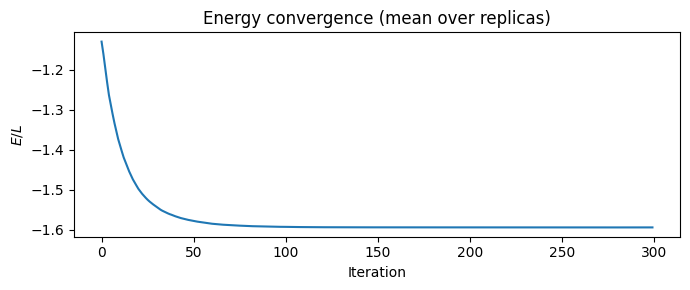

In [5]:
with open(os.path.join(run_dir, "log.log")) as f:
    log_data = json.load(f)

iters  = np.array(log_data["AvgEnergyReplicas"]["iters"])
E_mean = np.array(log_data["AvgEnergyReplicas"]["Mean"])

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(iters, E_mean / L_r)
ax.set_xlabel("Iteration")
ax.set_ylabel("$E / L$")
ax.set_title("Energy convergence (mean over replicas)")
plt.tight_layout()
plt.show()

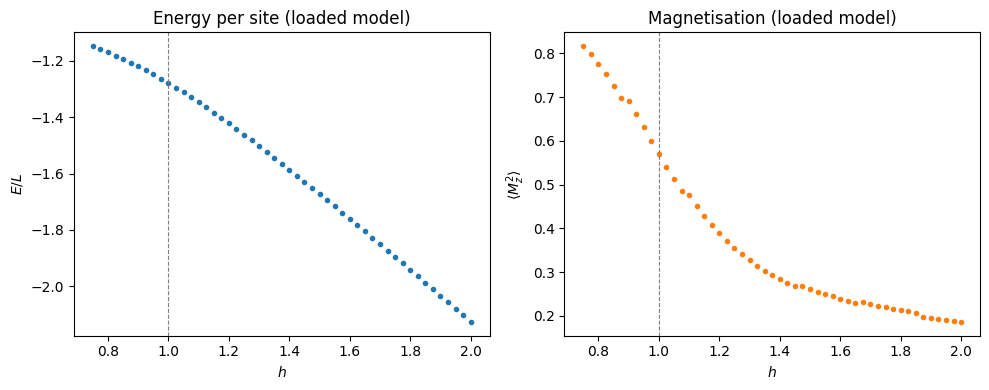

In [6]:
Mz  = sum(nkf.operator.sigmaz(hi_r, i) for i in range(L_r)) * (1.0 / L_r)
Mz2 = Mz @ Mz

h_anchors = np.linspace(meta["h_min"] + 0.05, meta["h_max"] - 0.05, 7)
h_sweep   = np.linspace(meta["h_min"], meta["h_max"], 51)

# Thermalise each anchor (MCMC until R-hat < rhat_tol) before using it as an
# IS reference — see Tutorial 3 for why un-thermalised references bias the sweep.
anchor_states = {}
for h0 in h_anchors:
    mc = vs_r.get_state(jnp.array([h0]))
    mc.n_samples = 4096
    mc.thermalise(create_operator_r(jnp.array([h0])), rhat_tol=1.03, verbose=False)
    anchor_states[h0] = mc

def nearest(h):
    return h_anchors[np.argmin(np.abs(h_anchors - h))]

is_E, is_Mz2 = [], []
for h0 in h_sweep:
    mc_ref = anchor_states[nearest(h0)]
    pars   = jnp.array([h0])
    # ISState caches weights; both .expect() calls below reuse them.
    is_st  = ISState.from_mc_state(mc_ref, pars)
    op     = create_operator_r(pars)
    is_E.append(float(is_st.expect(op).mean.real))
    is_Mz2.append(float(is_st.expect(Mz2).mean.real))

is_E, is_Mz2 = np.array(is_E), np.array(is_Mz2)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(h_sweep, is_E / L_r, "o", ms=3, color="tab:blue")
axes[0].axvline(1.0, ls="--", color="gray", lw=0.8)
axes[0].set_xlabel("$h$")
axes[0].set_ylabel("$E / L$")
axes[0].set_title("Energy per site (loaded model)")

axes[1].plot(h_sweep, is_Mz2, "o", ms=3, color="tab:orange")
axes[1].axvline(1.0, ls="--", color="gray", lw=0.8)
axes[1].set_xlabel("$h$")
axes[1].set_ylabel(r"$\langle M_z^2 \rangle$")
axes[1].set_title("Magnetisation (loaded model)")

plt.tight_layout()
plt.show()